# Random Forest.
## Grupo 2.

### Importación de librerías.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from pathlib import Path
import tensorflow as tf
import joblib

### Direcciones y etiquetas distintas.

In [12]:
TRAIN_DIR = Path('train')
TEST_DIR = Path('test')
ETIQUETAS = {'del': '.',
             'spa': '_',
             'not': ' '}
DIM_IMAGEN = (64,64)

### Datos de entrenamieto.

In [13]:
# Listado de rutas de imágenes.
imagenes_train = list(TRAIN_DIR.glob("*.jpg"))
nombres_imagenes = [str(texto).rsplit('\\', 1)[-1] for texto in imagenes_train]

etiquetas_train = []
for x in nombres_imagenes:
    if x[0:3] in ['del', 'spa', 'not']:
        etiquetas_train.append(ETIQUETAS[x[0:3]])
    else:
        etiquetas_train.append(x[0])
etiquetas_train = np.array(etiquetas_train)

# Semilla, tamaño de lote y generador de aleatorios.
seed = 42
batch_size = 2900
rng = np.random.default_rng(seed)

# Etiquetas únicas
clases = np.unique(etiquetas_train)
n_por_clase = batch_size // len(clases)
n_batches = len(etiquetas_train) // batch_size

indices_clase = {c: np.where(etiquetas_train == c)[0] for c in clases}
lotes = []

for _ in range(n_batches):
    lote = []
    for c in clases:
        idx = indices_clase[c]
        seleccion = rng.choice(idx, size=n_por_clase, replace=len(idx) < n_por_clase)
        lote.extend(seleccion)
    rng.shuffle(lote)
    lotes.append(lote)

class_to_idx = {c:i for i,c in enumerate(clases)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
train_labels = np.array([class_to_idx[x] for x in etiquetas_train], dtype=np.int32)

# Elección de imágenes que se cambiarán.
indices_lote = np.asarray(lotes[0])

# Imágenes del lote de entrenamiento.
imagenes = []
for i in indices_lote:
    img = tf.keras.utils.load_img(imagenes_train[i], target_size=DIM_IMAGEN)
    imagenes.append(tf.keras.utils.img_to_array(img))

# Conjunto de entrenamiento original.
X_train = np.asarray(imagenes, dtype=np.float32) / 255.0
y_train = train_labels[indices_lote]

### Conjunto de prueba.

In [17]:
# Listado de rutas de imágenes.
imagenes_test = list(TEST_DIR.glob("*.jpg"))
nombres_imagenes_test = [str(texto).rsplit('\\', 1)[-1] for texto in imagenes_test]

# Etiquetas test
etiquetas_test = []
for x in nombres_imagenes_test:
    if x[0:3] in ['del', 'spa', 'not']:
        etiquetas_test.append(ETIQUETAS[x[0:3]])
    else:
        etiquetas_test.append(x[0])
etiquetas_test = np.array(etiquetas_test)
test_labels = np.array([class_to_idx[x] for x in etiquetas_test], dtype=np.int32)

imagenes_prueba = []
for i in imagenes_test:
    img = tf.keras.utils.load_img(i, target_size=DIM_IMAGEN)
    imagenes_prueba.append(tf.keras.utils.img_to_array(img))

X_test = np.asarray(imagenes_prueba, dtype=np.float32) / 255.0
y_test = test_labels

### Redimensionando los datos de entrenamiento y prueba.

In [24]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

### Modelo

In [20]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

### Rejillas de hiperparámetros.

In [21]:
param_grid = {"n_estimators": [100, 200, 300],
              "max_depth": [None, 10, 20],
              "min_samples_split": [2, 5],
              "min_samples_leaf": [1, 2],
              "max_features": ["sqrt", "log2"]
              }

### GridSearch.

In [22]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

### Entrenamiento del modelo.

In [25]:
grid_search.fit(X_train_rf, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


### Mejor modelo.

In [26]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor accuracy en validación cruzada:")
print(grid_search.best_score_)

Mejores hiperparámetros:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Mejor accuracy en validación cruzada:
0.8541379310344828


### Predicción y error.

In [28]:
y_pred = grid_search.predict(X_test_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))



Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9802    0.9900       101
           1     0.8800    0.8800    0.8800       100
           2     0.8163    0.7921    0.8040       101
           3     0.8077    0.8317    0.8195       101
           4     0.8922    0.9010    0.8966       101
           5     0.7917    0.7525    0.7716       101
           6     0.7714    0.8020    0.7864       101
           7     0.8283    0.8119    0.8200       101
           8     0.8364    0.9109    0.8720       101
           9     0.8932    0.9109    0.9020       101
          10     0.9126    0.9307    0.9216       101
          11     0.9024    0.7327    0.8087       101
          12     0.8455    0.9208    0.8815       101
          13     0.9340    0.9802    0.9565       101
          14     0.9583    0.9109    0.9340       101
          15     0.9608    0.9703    0.9655       101
          16     0.9307    0.9307    0.9307       101
   

### Matriz de confusión.

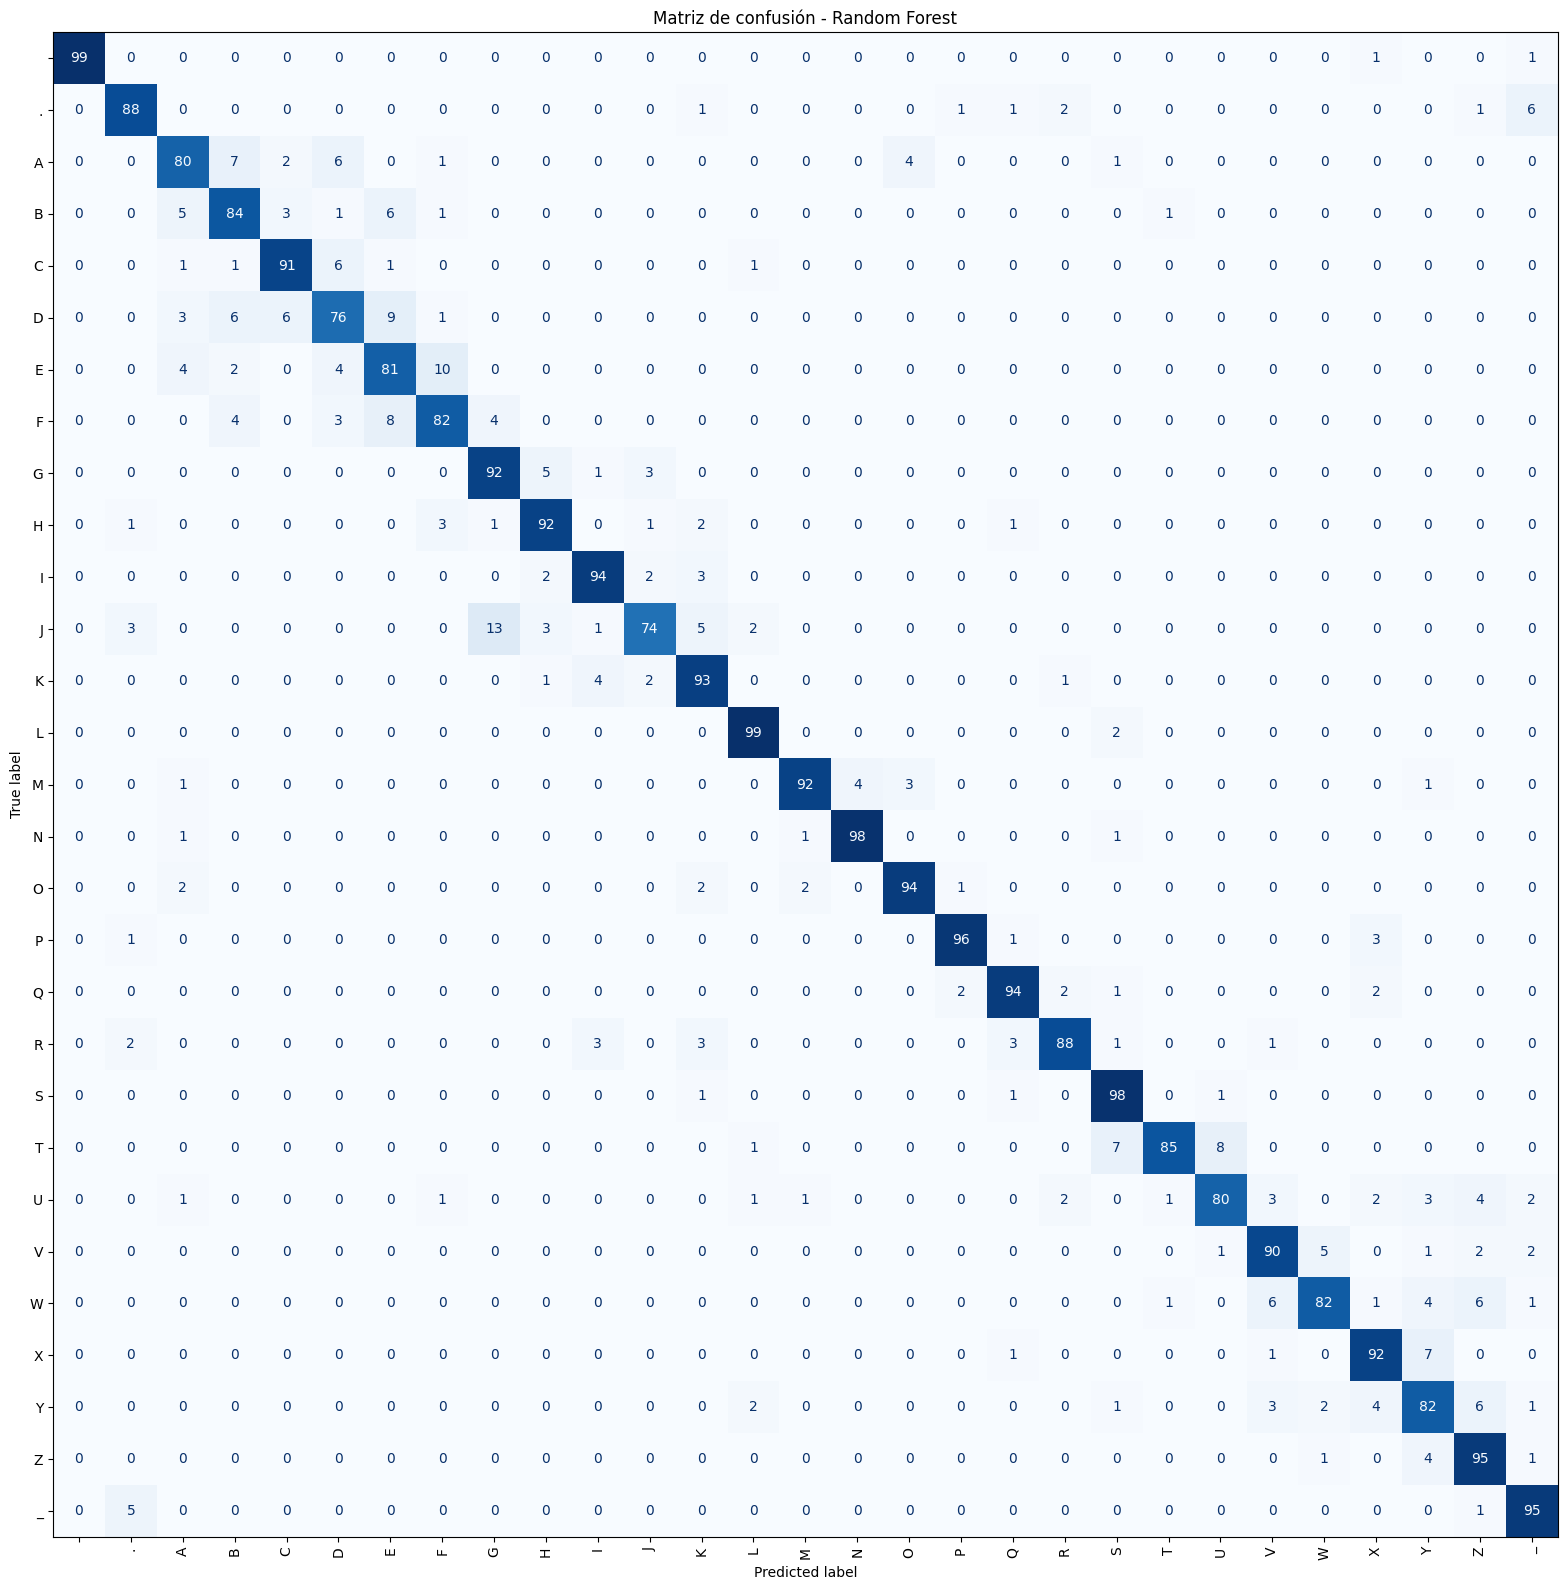

In [30]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(16, 16))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[idx_to_class[i] for i in range(29)])
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

### Guardando el modelo.

In [33]:
mejor_modelo = grid_search.best_estimator_
joblib.dump(mejor_modelo,"random_forest.pkl")

['random_forest.pkl']

### Explicación y rendimiento.

Este modelo mostró ser mejor que los modelos anteriores, obteniendo un accuracy del 88%.  
Se eligió este modelo debido a que permite tener varias decisiones que disminuyan la varianza de las predicciones.  
Al modelo lo que más se le complicó fue la letra D y J.